# Resumo: os Três Casos e a Estabilidade

Nas últimas três aulas, resolvemos $\mathbf{x}'=A\mathbf{x}$ nos três casos possíveis para os autovalores. Vamos amarrar tudo num único resultado, como fizemos para as equações de segunda ordem, e depois organizar a estabilidade dos sistemas $2\times2$ numa única figura.

## Os três casos para sistemas $2\times2$

**Teorema.** Seja $A$ uma matriz $2\times2$ real, com equação característica $\lambda^2-(\operatorname{tr}A)\lambda+\det A=0$ e discriminante $\Delta=(\operatorname{tr}A)^2-4\det A$. Então o sistema $\mathbf{x}'=A\mathbf{x}$ sempre tem duas soluções linearmente independentes, todo PVI $\mathbf{x}(t_0)=\mathbf{x}_0$ tem solução única, e a solução geral é dada por:

| $\Delta$ | Autovalores | Solução geral |
|---|---|---|
| $\Delta>0$ | $\lambda_1\neq\lambda_2$ reais | $c_1\mathbf{v}^{(1)}e^{\lambda_1t}+c_2\mathbf{v}^{(2)}e^{\lambda_2t}$ |
| $\Delta<0$ | $\alpha\pm i\beta$, autovetor $\mathbf{a}+i\mathbf{b}$ | $c_1e^{\alpha t}(\mathbf{a}\cos\beta t-\mathbf{b}\,\text{sen}\,\beta t)+c_2e^{\alpha t}(\mathbf{a}\,\text{sen}\,\beta t+\mathbf{b}\cos\beta t)$ |
| $\Delta=0$ | $\lambda$ duplo, um autovetor $\mathbf{v}$ | $c_1\mathbf{v}e^{\lambda t}+c_2(\mathbf{v}te^{\lambda t}+\mathbf{w}e^{\lambda t})$, com $(A-\lambda I)\mathbf{w}=\mathbf{v}$ |

(No caso $\Delta=0$ com dois autovetores, ou seja $A=\lambda I$, vale a primeira linha com $\lambda_1=\lambda_2$.) Em cada caso, o determinante $W$ formado pelas duas soluções nunca se anula, então elas são independentes e geram todas as soluções.

O mesmo vale para sistemas $n\times n$: sempre é possível encontrar $n$ soluções independentes, combinando os três tipos de construção (autovetores, partes real e imaginária, e autovetores generalizados, que podem exigir potências maiores de $t$). Há uma analogia completa com o que vimos para equações de ordem $n$: as raízes da equação característica fazem o papel dos autovalores, e cada tipo de raiz contribui com o mesmo tipo de função.

Vamos conferir os três casos com os exemplos das aulas anteriores:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

t = sp.symbols('t', real=True)
casos = {
    "reais distintos": (sp.Matrix([[1, 1], [4, 1]]),
                        [sp.Matrix([1, 2])*sp.exp(3*t), sp.Matrix([1, -2])*sp.exp(-t)]),
    "complexos": (sp.Matrix([[-sp.Rational(1, 2), 1], [-1, -sp.Rational(1, 2)]]),
                  [sp.exp(-t/2)*sp.Matrix([sp.cos(t), -sp.sin(t)]), sp.exp(-t/2)*sp.Matrix([sp.sin(t), sp.cos(t)])]),
    "repetido": (sp.Matrix([[1, -1], [1, 3]]),
                 [sp.Matrix([1, -1])*sp.exp(2*t), sp.Matrix([1, -1])*t*sp.exp(2*t) + sp.Matrix([0, -1])*sp.exp(2*t)]),
}
for nome, (A, (x1, x2)) in casos.items():
    ok = [sp.simplify(x.diff(t) - A*x) == sp.zeros(2, 1) for x in (x1, x2)]
    W = sp.simplify(sp.Matrix.hstack(x1, x2).det())
    print(f"{nome:16s} soluções ok: {ok}   W(t) = {W}")

reais distintos  soluções ok: [True, True]   W(t) = -4*exp(2*t)
complexos        soluções ok: [True, True]   W(t) = exp(-t)
repetido         soluções ok: [True, True]   W(t) = -exp(4*t)


## Estabilidade dos sistemas $2\times2$

Juntando os resumos das três aulas, o retrato de fase e a estabilidade da origem dependem apenas dos autovalores:

| Autovalores | Retrato de fase | Estabilidade |
|---|---|---|
| reais, $\lambda_1<0<\lambda_2$ | sela | instável |
| reais, ambos negativos | nó estável | assintoticamente estável |
| reais, ambos positivos | nó instável | instável |
| $\alpha\pm i\beta$, $\alpha<0$ | foco estável | assintoticamente estável |
| $\pm i\beta$ ($\alpha=0$) | centro | estável |
| $\alpha\pm i\beta$, $\alpha>0$ | foco instável | instável |
| duplo, negativo | nó impróprio (ou próprio) estável | assintoticamente estável |
| duplo, positivo | nó impróprio (ou próprio) instável | instável |

Em uma frase: **a origem é assintoticamente estável quando todos os autovalores têm parte real negativa**, e instável quando algum tem parte real positiva.

## O diagrama traço–determinante

Como os autovalores de uma matriz $2\times2$ são as raízes de $\lambda^2-(\operatorname{tr}A)\lambda+\det A=0$, toda essa classificação pode ser lida diretamente de **dois números**: o traço e o determinante. Lembrando que $\lambda_1+\lambda_2=\operatorname{tr}A$, $\lambda_1\lambda_2=\det A$ e $\Delta=(\operatorname{tr}A)^2-4\det A$:

* $\det A<0$: autovalores reais de sinais opostos — **sela**.
* $\det A>0$ e $\Delta>0$ (abaixo da parábola $\det A=\tfrac14(\operatorname{tr}A)^2$): autovalores reais de mesmo sinal, o do traço — **nó**, estável se $\operatorname{tr}A<0$ e instável se $\operatorname{tr}A>0$.
* $\Delta<0$ (acima da parábola): autovalores complexos com parte real $\tfrac12\operatorname{tr}A$ — **foco**, estável se $\operatorname{tr}A<0$, instável se $\operatorname{tr}A>0$, e **centro** sobre o eixo $\operatorname{tr}A=0$.
* Sobre a parábola ($\Delta=0$): autovalor duplo — **nó impróprio** (ou próprio).

Tudo isso cabe num único desenho, o **diagrama traço–determinante**. Cada ponto do plano $(\operatorname{tr}A,\det A)$ corresponde a um tipo de retrato de fase; os pequenos retratos mostram um exemplo de cada região:

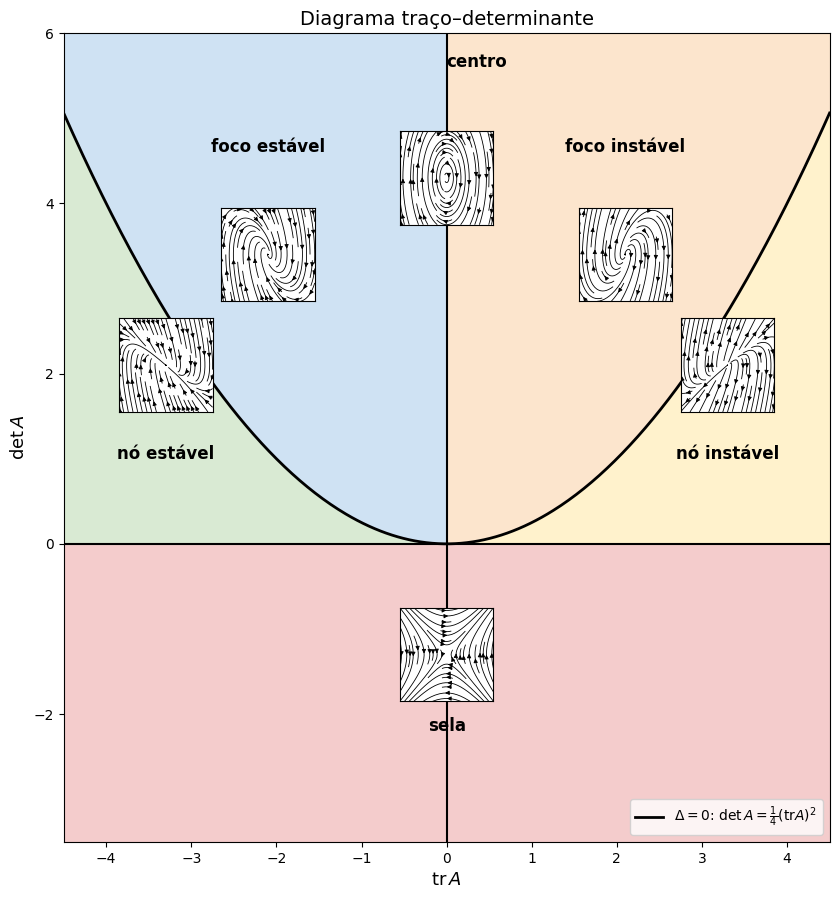

In [2]:
def mini_retrato(tr, det, ax):
    A = np.array([[0, 1], [-det, tr]])     # uma matriz com esse traço e esse determinante
    s = np.linspace(-1, 1, 25)
    X, Y = np.meshgrid(s, s)
    ax.streamplot(X, Y, A[0, 0]*X + A[0, 1]*Y, A[1, 0]*X + A[1, 1]*Y,
                  color='k', density=0.7, linewidth=0.6, arrowsize=0.6)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
    ax.set_facecolor('white')

fig, ax = plt.subplots(figsize=(10, 10.5))
tr = np.linspace(-4.5, 4.5, 400)
par = tr**2/4
ax.fill_between(tr, -3.5, 0, color='#f4cccc')                               # sela
ax.fill_between(tr, par, 6, where=tr <= 0, color='#cfe2f3')                 # foco estável
ax.fill_between(tr, par, 6, where=tr >= 0, color='#fce5cd')                 # foco instável
ax.fill_between(tr, 0, np.minimum(par, 6), where=tr <= 0, color='#d9ead3')  # nó estável
ax.fill_between(tr, 0, np.minimum(par, 6), where=tr >= 0, color='#fff2cc')  # nó instável
ax.plot(tr, par, 'k', linewidth=2, label=r'$\Delta=0$: $\det A=\frac{1}{4}(\mathrm{tr}A)^2$')
ax.axhline(0, color='k', linewidth=1.5); ax.axvline(0, color='k', linewidth=1.5)

rotulos = [(0, -2.2, 'sela'), (-3.3, 1.0, 'nó estável'), (3.3, 1.0, 'nó instável'),
           (-2.1, 4.6, 'foco estável'), (2.1, 4.6, 'foco instável'), (0.35, 5.6, 'centro')]
for x, y, texto in rotulos:
    ax.text(x, y, texto, ha='center', fontsize=12, fontweight='bold')

exemplos = [(0, -1.3), (-3.3, 2.1), (3.3, 2.1), (-2.1, 3.4), (2.1, 3.4), (0, 4.3)]
for x, y in exemplos:
    ins = ax.inset_axes([x - 0.55, y - 0.55, 1.1, 1.1], transform=ax.transData)
    mini_retrato(x, y, ins)

ax.set_xlim(-4.5, 4.5); ax.set_ylim(-3.5, 6); ax.set_aspect('equal')
ax.set_xlabel(r"$\mathrm{tr}\,A$", fontsize=13); ax.set_ylabel(r"$\det A$", fontsize=13)
ax.set_title("Diagrama traço–determinante", fontsize=14)
ax.legend(loc='lower right')
plt.show()

Repare que a região de estabilidade assintótica é o **segundo quadrante**: $\operatorname{tr}A<0$ e $\det A>0$. Essa é uma forma rápida de testar a estabilidade de um sistema $2\times2$ sem calcular autovalores. Em engenharia de controle, esse critério (e sua generalização para ordens maiores, o critério de Routh–Hurwitz) é usado para decidir se um sistema realimentado é estável.

### O oscilador harmônico no diagrama

O oscilador $x''+\gamma x'+kx=0$ (com $m=1$), escrito como sistema, tem $\operatorname{tr}A=-\gamma$ e $\det A=k$. Fixando a mola ($k=1$) e aumentando o amortecimento $\gamma$ de $0$ a $3$, o ponto $(\operatorname{tr}A,\det A)=(-\gamma,1)$ anda para a esquerda numa reta horizontal: começa no **centro** (sem amortecimento), passa pela região dos **focos estáveis** (subamortecido), cruza a parábola em $\gamma=2$ (**amortecimento crítico**, autovalor duplo) e entra na região dos **nós estáveis** (superamortecido). Os quatro regimes das vibrações livres são quatro regiões do diagrama:

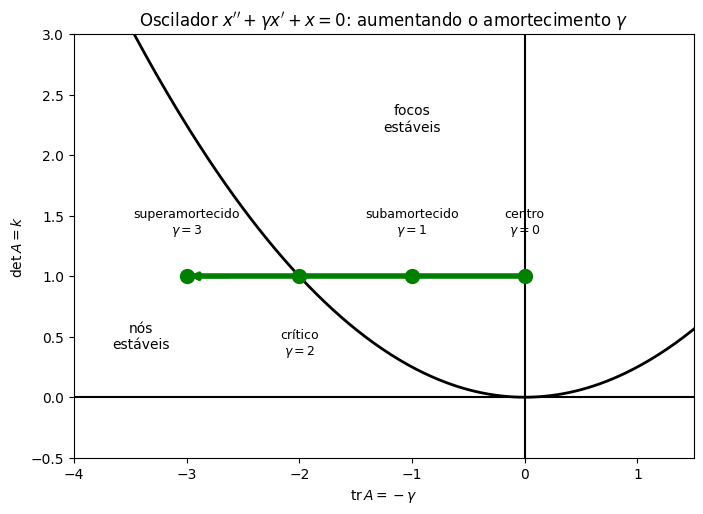

In [3]:
fig, ax = plt.subplots(figsize=(8, 5.5))
tr = np.linspace(-4, 1.5, 300)
ax.plot(tr, tr**2/4, 'k', linewidth=2)
ax.axhline(0, color='k'); ax.axvline(0, color='k')
ax.text(-3.4, 0.4, 'nós\nestáveis', ha='center'); ax.text(-1.0, 2.2, 'focos\nestáveis', ha='center')

gammas = np.linspace(0, 3, 100)
ax.plot(-gammas, np.ones_like(gammas), 'g', linewidth=4)
ax.annotate('', xy=(-3, 1), xytext=(-2.6, 1), arrowprops=dict(arrowstyle='-|>', color='g', lw=3))
for g, nome in [(0, 'centro\n$\\gamma=0$'), (1, 'subamortecido\n$\\gamma=1$'),
                (2, 'crítico\n$\\gamma=2$'), (3, 'superamortecido\n$\\gamma=3$')]:
    ax.plot(-g, 1, 'go', markersize=10)
    ax.annotate(nome, (-g, 1), xytext=(-g, 1.35 if g != 2 else 0.35), ha='center', fontsize=9)

ax.set_xlim(-4, 1.5); ax.set_ylim(-0.5, 3)
ax.set_xlabel(r"$\mathrm{tr}\,A=-\gamma$"); ax.set_ylabel(r"$\det A=k$")
ax.set_title(r"Oscilador $x''+\gamma x'+x=0$: aumentando o amortecimento $\gamma$")
plt.show()

É a mesma história do diagrama de bifurcação que desenhamos no plano complexo, na aula de vibrações livres — só que agora contada com traço e determinante, e valendo para **qualquer** sistema $2\times2$, não só para osciladores.